In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
start = "2020-10-01"
end = "2024-10-01"

symbol = "AMZN"

df = yf.download(symbol, start, end)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-10-01,160.399994,161.199997,158.600006,161.063004,161.063004,99438000
2020-10-02,157.681503,159.789993,156.149994,156.250000,156.250000,112262000
2020-10-05,157.292007,160.126495,157.042496,159.960007,159.960007,75506000
2020-10-06,158.250000,159.100006,154.500000,154.998001,154.998001,101738000
2020-10-07,156.750000,160.000000,156.619507,159.784500,159.784500,86188000


### 이상치 추출 방법

In [4]:
# IQR 방법을 사용한 이상치 추출
def detect_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [5]:
# 이상치 추출
outliers_iqr = detect_outliers_iqr(df[['Open', 'High', 'Low', 'Close', 'Volume']])

print(outliers_iqr)

                  Open        High         Low       Close     Volume
Date                                                                 
2020-10-12  167.496994  174.811996  166.977493  172.146500  167284000
2020-10-16  168.161499  169.983002  158.000000  163.635498  129488000
2020-10-26  159.936996  164.149002  157.664993  160.352005  118024000
2020-10-29  160.063507  162.862503  158.199997  160.550507  131930000
2020-10-30  157.887497  158.350006  150.949997  151.807495  167728000
2020-11-02  153.087006  153.985504  147.505997  150.223999  145148000
2020-11-04  157.999496  162.242493  156.986496  162.057999  136780000
2020-11-09  161.551498  164.449997  155.605499  157.186996  143808000
2020-11-10  154.751007  155.699997  150.973999  151.751007  131820000
2020-12-18  162.199493  162.470993  158.580002  160.082504  119914000
2021-02-02  169.000000  171.386993  168.056503  169.000000  141972000
2021-02-03  171.250504  171.699997  165.431000  165.626495  141776000
2021-04-29  175.2550

In [6]:
# Z-점수 방법을 사용한 이상치 추출
def detect_outliers_zscore(df, threshold=3):
    z_scores = np.abs((df - df.mean()) / df.std())
    return df[(z_scores > threshold).any(axis=1)]

In [7]:
outliers_zscore = detect_outliers_zscore(df[['Open', 'High', 'Low', 'Close', 'Volume']])

print(outliers_zscore)

                  Open        High         Low       Close     Volume
Date                                                                 
2020-10-12  167.496994  174.811996  166.977493  172.146500  167284000
2020-10-30  157.887497  158.350006  150.949997  151.807495  167728000
2021-04-29  175.255005  175.722504  171.750000  173.565506  153648000
2021-07-30  167.397507  168.406998  165.348999  166.379501  199312000
2022-01-21  149.949997  150.899994  142.070496  142.643005  163972000
2022-01-24  139.000000  144.945007  135.352005  144.544006  155624000
2022-02-03  141.737503  144.247498  138.332993  138.845505  225532000
2022-02-04  155.606506  161.199997  150.608002  157.639496  253456000
2022-04-29  129.848999  130.761002  121.625000  124.281502  272662000
2022-10-28   97.910004  103.959999   97.660004  103.410004  223133400
2022-11-01  103.989998  104.580002   96.059998   96.790001  153370000
2022-11-10   92.940002   98.690002   91.650002   96.629997  173414900
2023-02-02  110.2500

### 이평선을 통한 구간 탐색

In [8]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

In [9]:
df

,Open,High,Low,Close,Adj Close,Volume,MA50,MA200
Date,,,,,,,,
2020-10-01,160.399994,161.199997,158.600006,161.063004,161.063004,99438000,NaN,NaN
2020-10-02,157.681503,159.789993,156.149994,156.250000,156.250000,112262000,NaN,NaN
2020-10-05,157.292007,160.126495,157.042496,159.960007,159.960007,75506000,NaN,NaN
2020-10-06,158.250000,159.100006,154.500000,154.998001,154.998001,101738000,NaN,NaN
2020-10-07,156.750000,160.000000,156.619507,159.784500,159.784500,86188000,NaN,NaN
...,...,...,...,...,...,...,...,...
2024-09-24,194.270004,195.369995,190.130005,193.960007,193.960007,43478900,178.876401,175.44115
2024-09-25,193.750000,193.949997,192.160004,192.529999,192.529999,26391100,178.866601,175.66940
2024-09-26,194.309998,194.529999,189.539993,191.160004,191.160004,36334900,178.931201,175.88810


In [10]:
# 포지션 변화 계산
df['Position'] = np.nan
df.iloc[200:, df.columns.get_loc('Position')] = np.where(df['MA50'][200:] > df['MA200'][200:], 1, 0)
df['Position'] = df['Position'].diff()

# 골든 크로스와 데드 크로스 출력
golden_cross = df[df['Position'] == 1]
dead_cross = df[df['Position'] == -1]

In [11]:
print("골든 크로스:")
df[(df['Position'] == 1)]

골든 크로스:


,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Position
Date,,,,,,,,,
2023-05-26,116.040001,121.5,116.019997,120.110001,120.110001,96779900,105.551,105.16765,1.0


In [12]:
print("\n데드 크로스:")
df[(df['Position'] == -1)]


데드 크로스:


,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Position
Date,,,,,,,,,
2022-01-25,142.242493,143.600006,138.145004,139.985992,139.985992,90824000,168.76998,169.269768,-1.0


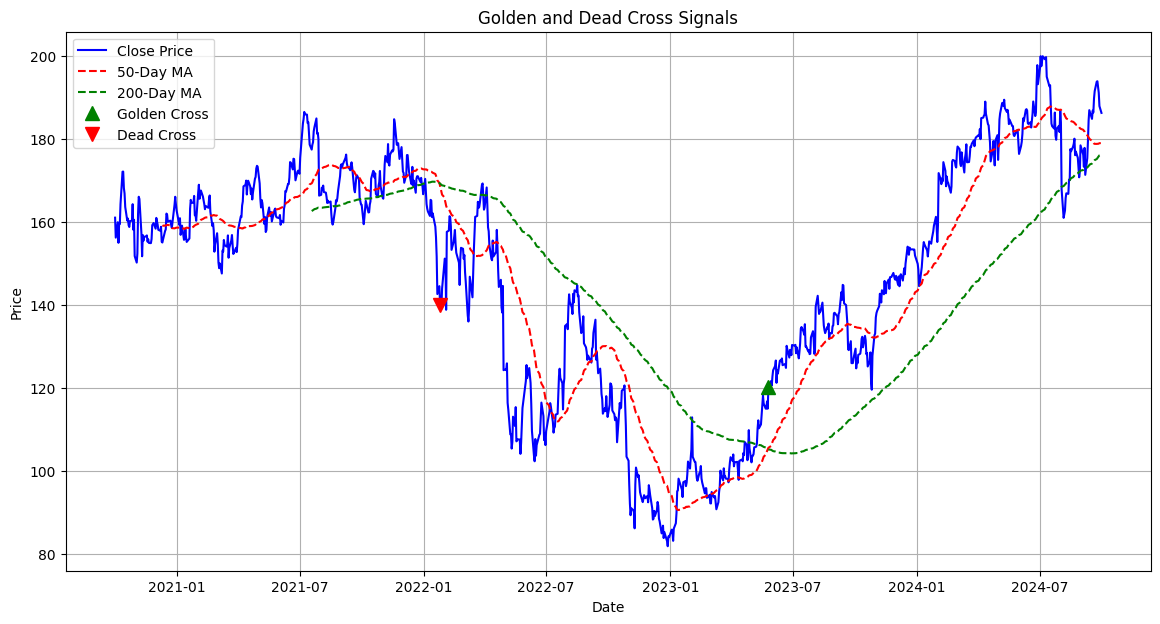

In [13]:
# 5. 그래프 그리기
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['MA50'], label='50-Day MA', color='red', linestyle='--')
plt.plot(df['MA200'], label='200-Day MA', color='green', linestyle='--')

# 매수 시그널 표시
plt.plot(golden_cross.index, df.loc[golden_cross.index, 'Close'], '^', markersize=10, color='g', label='Golden Cross')
plt.plot(dead_cross.index, df.loc[dead_cross.index, 'Close'], 'v', markersize=10, color='r', label='Dead Cross')

plt.title('Golden and Dead Cross Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()